In [1]:
import sys
sys.path.append('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/')
from pathlib import Path
from meteofetch import Arome0025
import get_meteo_dataset
import generate_maps

%load_ext autoreload
%autoreload 2

In [4]:
datasets = get_meteo_dataset.get_latest_forecast(
    'IP1', 
    Path('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs'),
    fields=['t', 'r'])


Files already up-to-date: ['/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__00H06H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__07H12H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__13H18H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__19H24H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__25H30H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__31H36H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__37H42H__2026-05-12T09-00-00Z.grib2', '/Users/qubo/L

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [ ]:
da_t = datasets["t"]  # Temperature at 2 meters
da_r = datasets["r"]  

layer_t = da_t.isel(time=0).sel(isobaricInhPa=1000)
layer_r = da_r.isel(time=0).sel(isobaricInhPa=1000)

import numpy as np
layer = 400 * ((layer_t - 273.15) - ((np.power(layer_r/100, 1/8) * (112+0.9*(layer_t - 273.15)) +  0.1*(layer_t - 273.15))-112))
# layer.rename('couldbase ft')

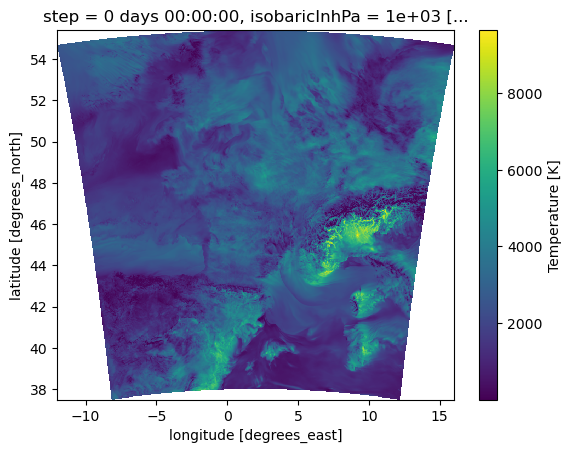

In [29]:
layer.plot()

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: Runt

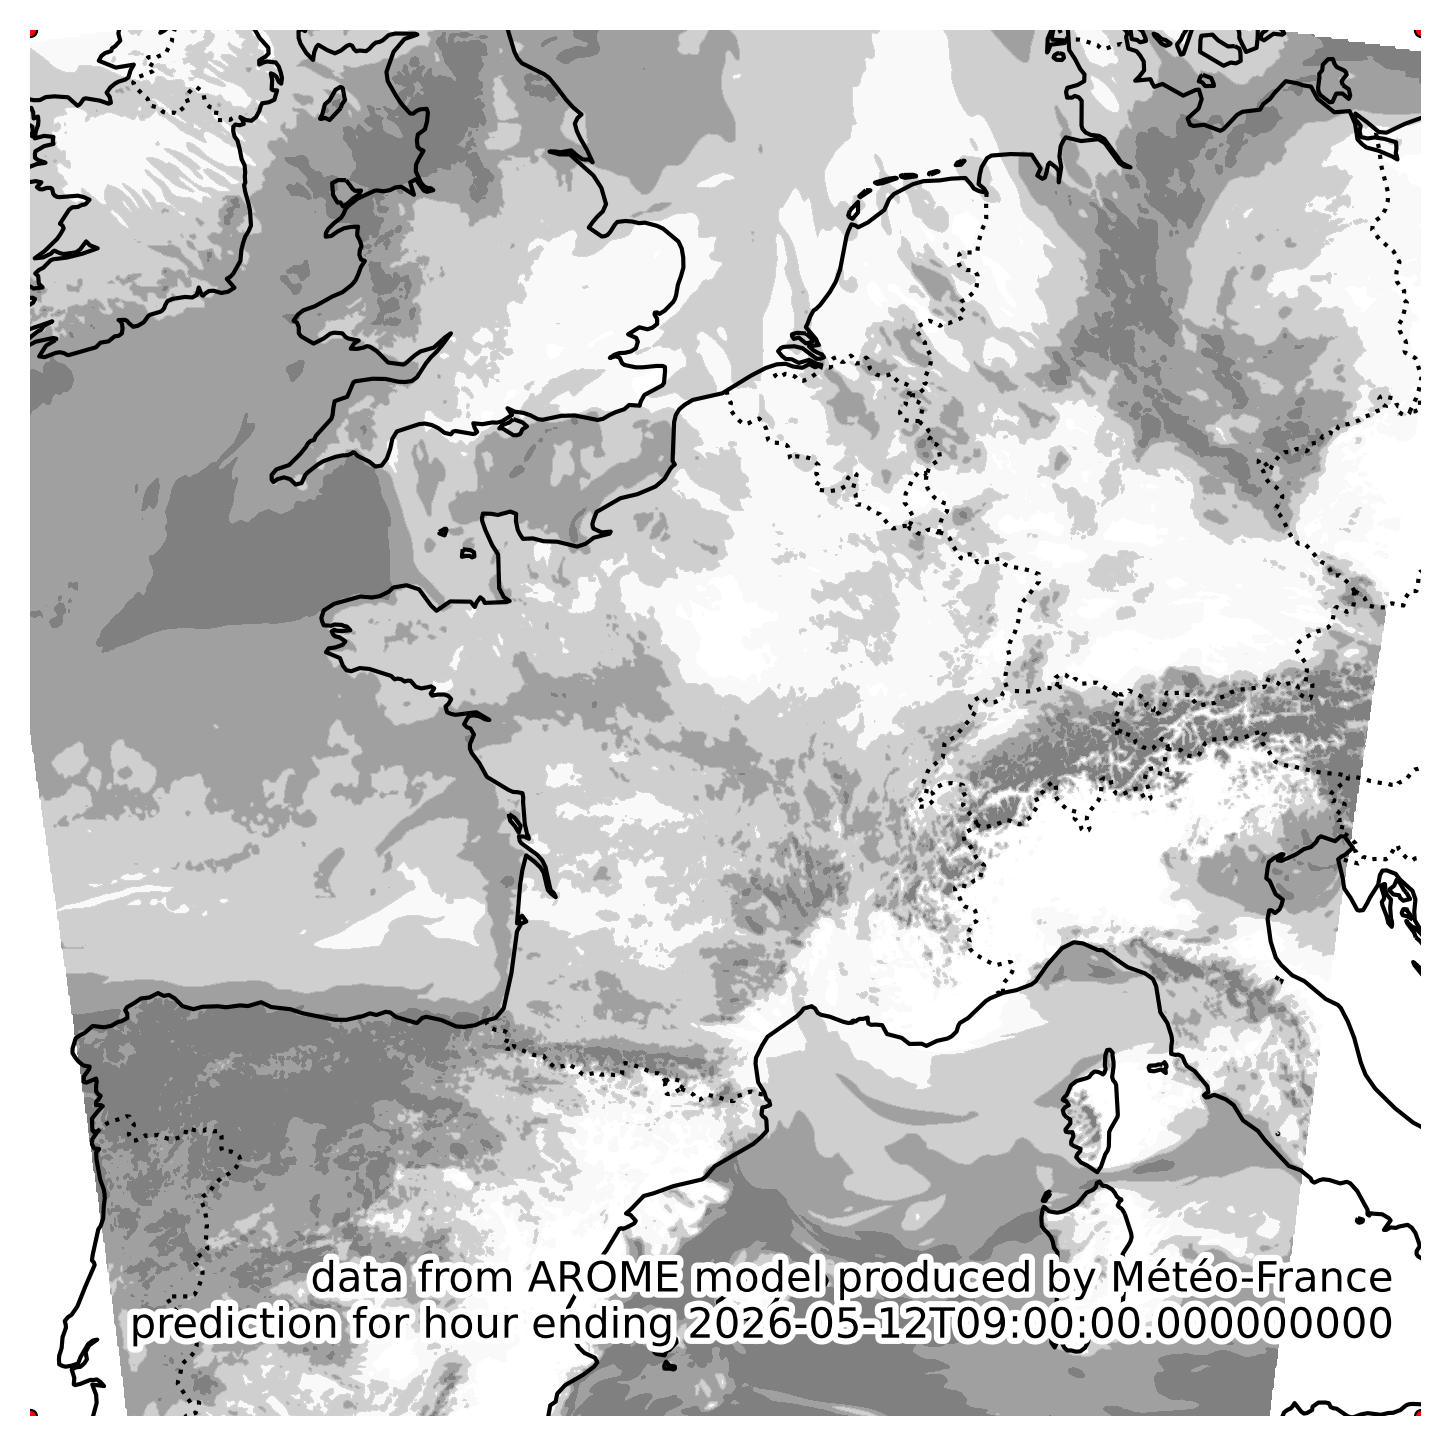

In [37]:
from matplotlib.colors import LinearSegmentedColormap
generate_maps.plot_layer_to_png(
    layer,
    output_path=Path("/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/wind_cloudbase.png"),
    show=True,
    vmin=0, 
    vmax=4000,
    levels=5,
    cmap = LinearSegmentedColormap.from_list("rain", [
        (0.25, 0.25, 0.25, 0.75),    # dark gray
        (0.5, 0.5, 0.5, 0.75),    # gray gray
        (0.75, 0.75, 0.75, 0.75),    # light gray
        (1, 1, 1, 0),    # Transparent white
    ], N=10)
)
